/tmp/ipykernel_1207/3697346935.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1207/3697346935.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_close = float(df['Close'].values[-1])
/tmp/ipykernel_1207/3697346935.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1207/3697346935.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performin

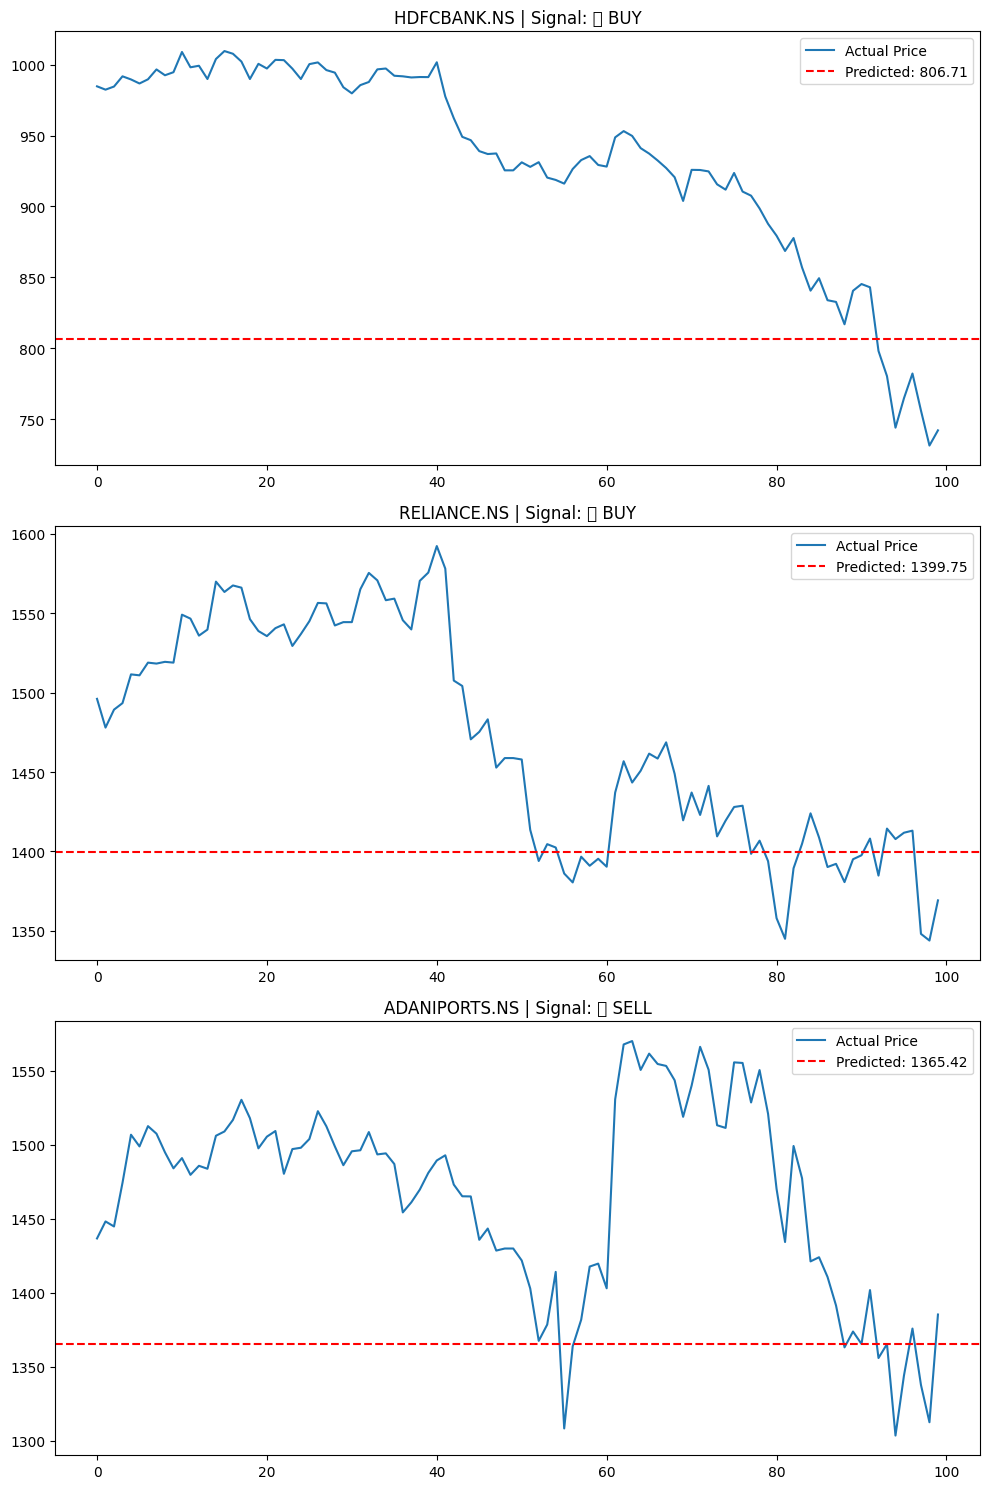

,Ticker,Last Close,Predicted,Change %,Signal,Status
0,HDFCBANK.NS,742.25,806.71,8.68%,🟢 BUY,✅ OK
1,RELIANCE.NS,1369.20,1399.75,2.23%,🟢 BUY,✅ OK
2,ADANIPORTS.NS,1385.40,1365.42,-1.44%,🔴 SELL,✅ OK


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os

def train_or_load_model(ticker, lookback=60, epochs=5):      #Fetch data and train/load LSTM model#

    try:
        df = yf.download(ticker, period="2y", interval="1d")
        if df.empty:
            return None, None, None  # Invalid ticker

        data = df[['Close']].values
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data)

        X_train, y_train = [], []
        for i in range(lookback, len(scaled_data)):
            X_train.append(scaled_data[i-lookback:i, 0])
            y_train.append(scaled_data[i, 0])

        X_train, y_train = np.array(X_train), np.array(y_train)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

        model_file = f"{ticker}_lstm.h5"
        if os.path.exists(model_file):
            model = load_model(model_file)
        else:
            model = Sequential([
                LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
                Dropout(0.2),
                LSTM(50, return_sequences=False),
                Dropout(0.2),
                Dense(25),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mean_squared_error")
            model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)
            model.save(model_file)

        return model, scaler, df

    except Exception:
        return None, None, None


def predict_multiple(tickers, lookback=60, epochs=5):
    results = []

    fig, axes = plt.subplots(len(tickers), 1, figsize=(10, 5*len(tickers)))
    if len(tickers) == 1:
        axes = [axes]  # make iterable

    for ax, ticker in zip(axes, tickers):
        model, scaler, df = train_or_load_model(ticker, lookback, epochs)

        if df is None or df.empty:
            results.append([ticker, "N/A", "N/A", "N/A", "N/A", "❌ Invalid Ticker"])
            ax.text(0.5, 0.5, f"{ticker}\n❌ Invalid Ticker",
                    fontsize=14, ha="center", va="center")
            ax.axis("off")
            continue

        # Prepare test data
        last_data = df['Close'].values[-lookback:]
        scaled_last = scaler.transform(last_data.reshape(-1, 1))
        X_test = np.reshape(scaled_last, (1, lookback, 1))

        pred_price = model.predict(X_test, verbose=0)
        pred_price = scaler.inverse_transform(pred_price)[0][0].item()
        last_close = float(df['Close'].values[-1])
        change = (pred_price - last_close) / last_close * 100

        # Signal
        if change > 0.5:
            signal = "🟢 BUY"
        elif change < -0.5:
            signal = "🔴 SELL"
        else:
            signal = "🟡 HOLD"

        results.append([ticker, f"{last_close:.2f}", f"{pred_price:.2f}",
                        f"{change:.2f}%", signal, "✅ OK"])

        # Plot
        ax.plot(df['Close'].values[-100:], label="Actual Price")
        ax.axhline(y=pred_price, color='r', linestyle='--',
                   label=f"Predicted: {pred_price:.2f}")
        ax.set_title(f"{ticker} | Signal: {signal}")
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Show summary table
    results_df = pd.DataFrame(results, columns=["Ticker", "Last Close", "Predicted",
                                                "Change %", "Signal", "Status"])
    return results_df

# To predict the results of Specific Companies of your choice
predict_multiple(["HDFCBANK.NS","RELIANCE.NS","ADANIPORTS.NS"],lookback=60, epochs=5)


/tmp/ipykernel_1207/3598755191.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipykernel_1207/3598755191.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_close = float(df['Close'].values[-1])
/tmp/ipykernel_1207/3598755191.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")

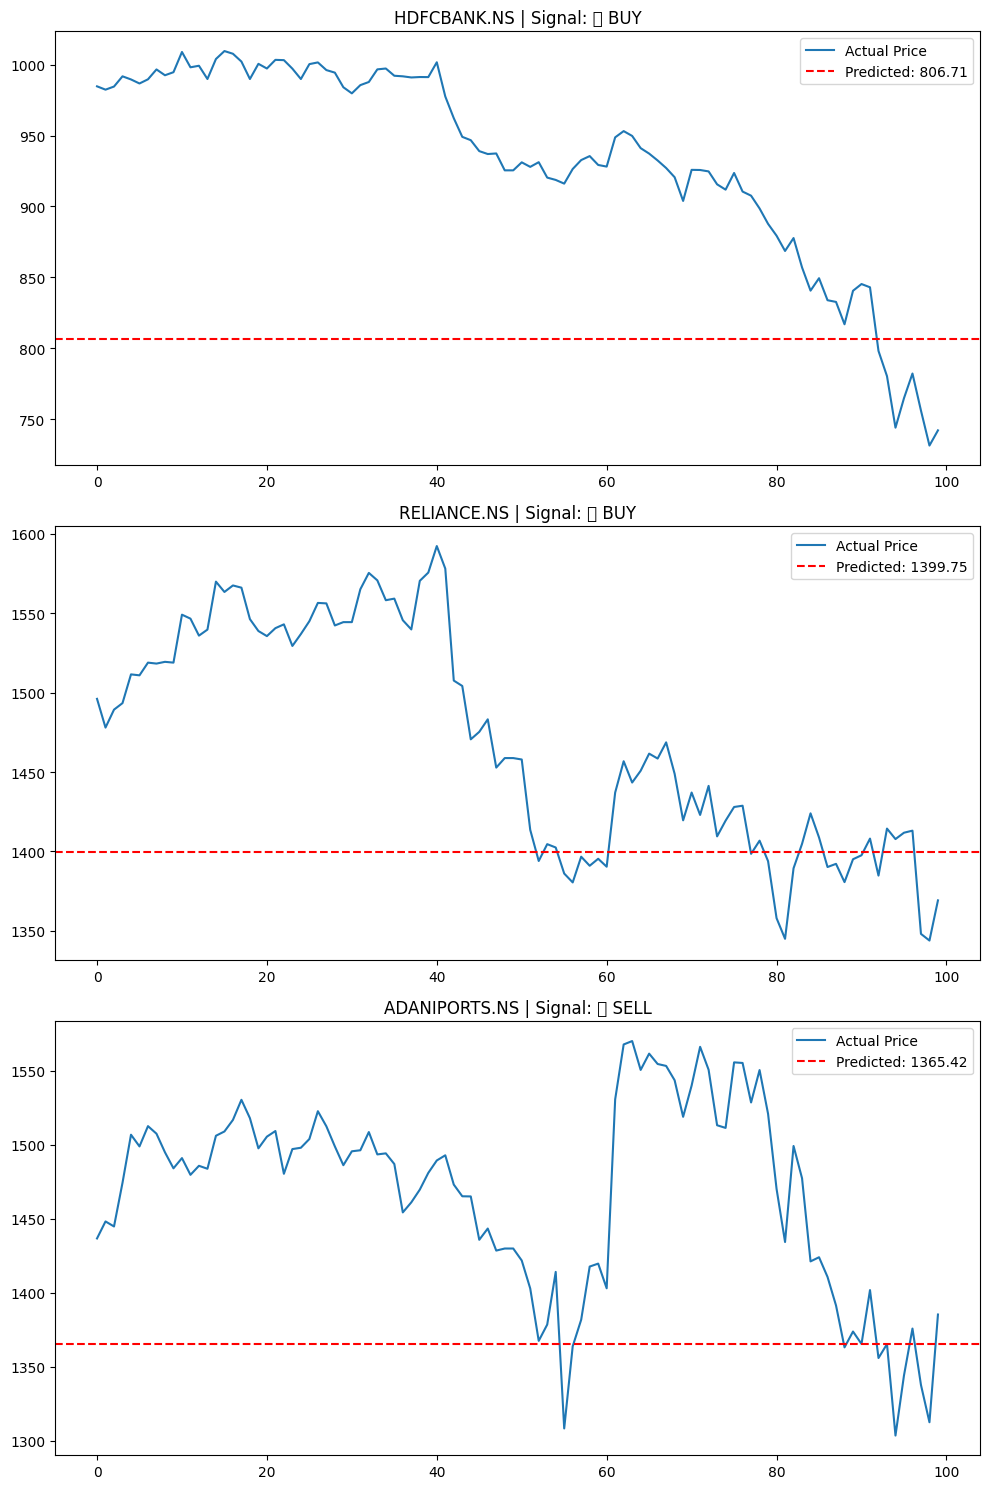

,Ticker,Last Close,Predicted,Change %,Signal,Status
0,HDFCBANK.NS,742.25,806.71,8.68%,🟢 BUY,✅ OK
1,RELIANCE.NS,1369.20,1399.75,2.23%,🟢 BUY,✅ OK
2,ADANIPORTS.NS,1385.40,1365.42,-1.44%,🔴 SELL,✅ OK


In [ ]:
predict_multiple(["HDFCBANK.NS","RELIANCE.NS","ADANIPORTS.NS"],lookback=60, epochs=5)

/tmp/ipython-input-3254231375.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3254231375.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_close = float(df['Close'].values[-1])
/tmp/ipython-input-3254231375.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as 

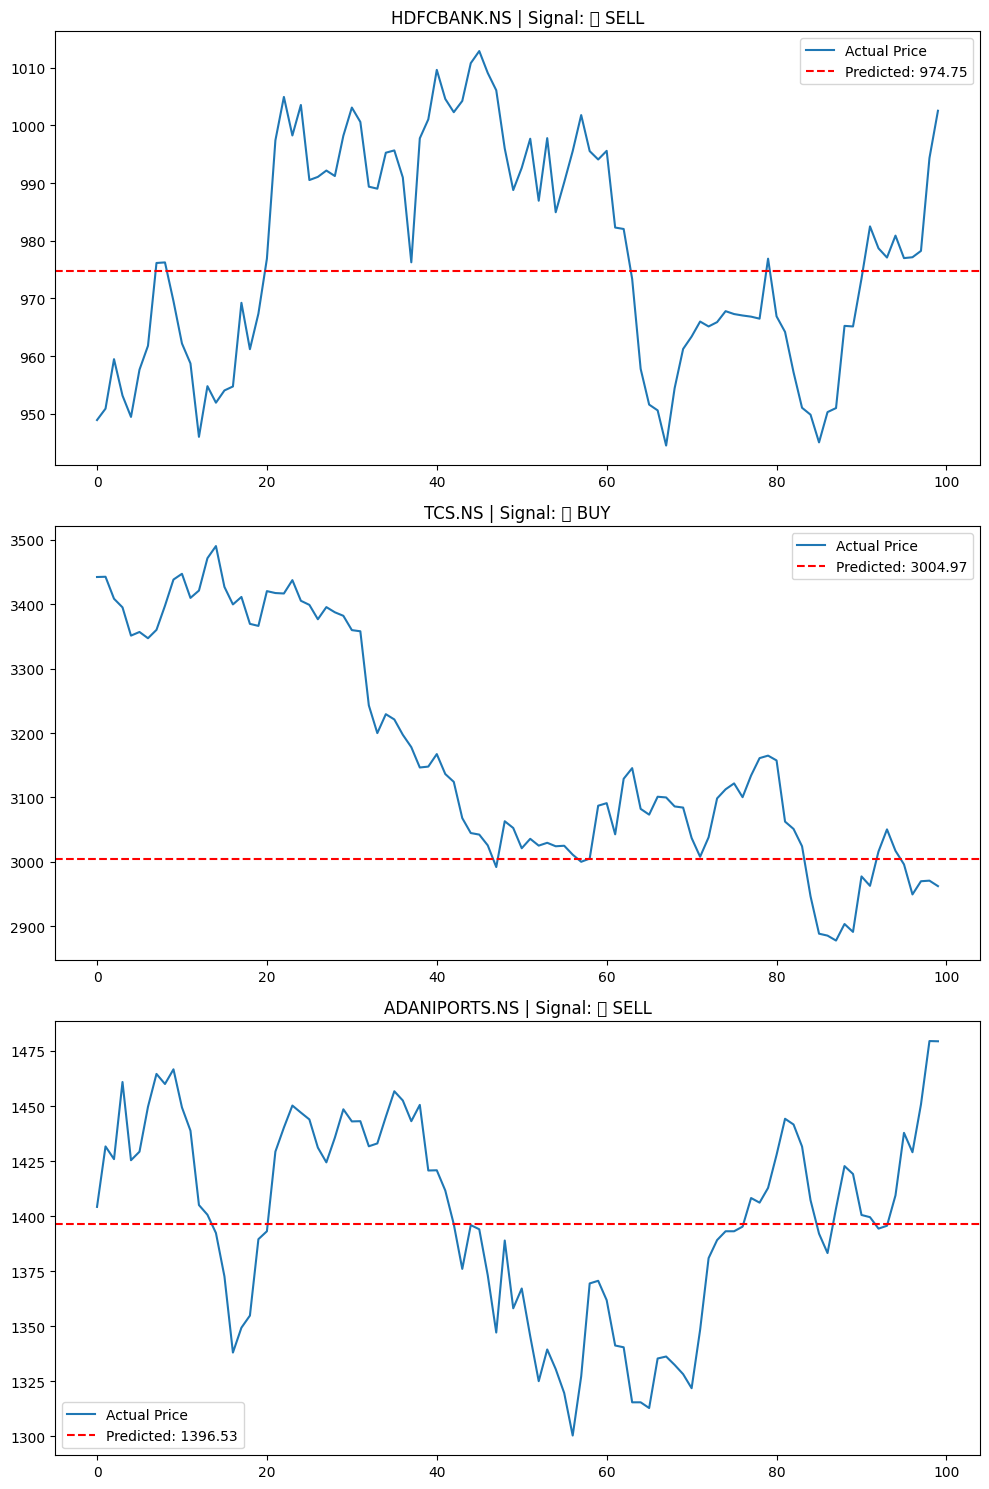

,Ticker,Last Close,Predicted,Change %,Signal,Status
0,HDFCBANK.NS,1002.55,974.75,-2.77%,🔴 SELL,✅ OK
1,TCS.NS,2962.20,3004.97,1.44%,🟢 BUY,✅ OK
2,ADANIPORTS.NS,1479.40,1396.53,-5.60%,🔴 SELL,✅ OK


In [ ]:
predict_multiple(["HDFCBANK.NS","TCS.NS","ADANIPORTS.NS"],lookback=60, epochs=5)